## Ficha de procedencia

- **Autor:** Pallares
- **Proyecto:** NovaMarket, Semana 8
- **Dataset de entrada:** `S07_PD_Arbelaez_DatasetSinOutliers.csv`
- **Dataset de salida:** `S08_PD_PallaresArbelaezSanchez_DatasetEscalado.csv`
- **Propósito:** escalar variables cuantitativas para la segmentación de clientes, sin fuga de datos entre entrenamiento y prueba.
- **Estado:** notebook ejecutado y validado en Python.

# S08 - Escalado de variables de NovaMarket

Este notebook parte de `S07_PD_Arbelaez_DatasetSinOutliers.csv` y prepara las variables cuantitativas relevantes para la segmentacion de clientes. Se conservan las columnas originales y se agrega una columna escalada por variable.

La division entrenamiento/prueba ocurre antes de ajustar cualquier escalador. Cada transformador se ajusta solo con entrenamiento y luego se aplica a entrenamiento y prueba, evitando fuga de datos.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler

RANDOM_STATE = 42
ARCHIVO_ENTRADA = Path('S07_PD_Arbelaez_DatasetSinOutliers.csv')
ARCHIVO_SALIDA = Path('S08_PD_PallaresArbelaezSanchez_DatasetEscalado.csv')
df = pd.read_csv(ARCHIVO_ENTRADA)
print(f'Dataset cargado: {df.shape[0]:,} filas y {df.shape[1]} columnas')
df.head(3)

Dataset cargado: 551,790 filas y 27 columnas


,id_pedido,id_cliente,fecha_pedido,canal_compra,metodo_pago,ciudad_tienda,codigo_postal,categoria_producto,producto,precio_unitario,...,peso_pedido_kg,fecha_actualizacion_stock,fuga_cliente,precio_monto_imputado,nivel_satisfaccion_imputado,ciudad_tienda_imputado,correo_cliente_imputado,comentario_cliente_imputado,es_venta_corporativa,monto_compra_capado
0,P505195,C45650,2025-11-15,Tienda,Efectivo,Bogota,1100103,Moda,Chaqueta impermeable,28700.0,...,14.9,2026-04-17,0,False,False,False,False,False,False,False
1,P677836,C84260,2026-03-05,Web,Efectivo,Manizales,1700101,Electronica,Parlante bluetooth,195700.0,...,12.9,2026-06-10,0,False,False,False,False,False,False,False
2,P481069,C98406,2025-06-27,App,Transferencia,Cucuta,5400103,Deportes,Colchoneta de yoga,322900.0,...,9.5,2026-05-14,0,False,False,False,False,False,False,False


## 1. Seleccion de variables

Se escalan `precio_unitario`, `unidades_vendidas`, `monto_compra`, `edad_cliente` y `peso_pedido_kg` porque describen magnitudes utiles para segmentar clientes. `codigo_postal` se conserva sin escalar: sus numeros son codigos categoricos, no una distancia. Los identificadores, fechas, textos, indicadores de imputacion y marcas de proceso tampoco son variables cuantitativas de segmentacion. `fuga_cliente` es una bandera binaria y se conserva sin convertirla artificialmente en una magnitud continua.

In [2]:
variables_escaladas = [
    'precio_unitario', 'unidades_vendidas', 'monto_compra',
    'edad_cliente', 'peso_pedido_kg'
]
resumen = df[variables_escaladas].describe().T
resumen['asimetria'] = df[variables_escaladas].skew()
resumen[['count', 'min', '50%', 'max', 'asimetria']]

,count,min,50%,max,asimetria
precio_unitario,551790.0,15100.0,305600.0,899600.0,0.566083
unidades_vendidas,551790.0,1.0,2.0,5.0,1.184019
monto_compra,551790.0,15800.0,476400.0,4457500.0,2.042959
edad_cliente,551790.0,-5.0,47.0,200.0,2.503216
peso_pedido_kg,551790.0,8.0,11.7,1399.9,4.241058


## 2. Eleccion de tecnica por columna

Se responden dos preguntas: (1) hay extremos o asimetria que puedan distorsionar media y desviacion?, y (2) conviene conservar un intervalo fijo o comparar desviaciones respecto al centro?

- `precio_unitario` -> **Z-score**: es continuo, tiene asimetria moderada y no conserva colas extremas relevantes tras la depuracion. Centrar en la media y dividir por la desviacion permite comparar precios en unidades de desviacion.
- `unidades_vendidas` -> **Robusto**: es discreta y sesgada a la derecha, con concentracion en pocos valores. Mediana y rango intercuartil representan mejor su escala que media y desviacion.
- `monto_compra` -> **Robusto**: aunque los outliers fueron tratados en la Semana 7, mantiene una cola derecha por la combinacion de precio y unidades. El rango intercuartil reduce su influencia.
- `edad_cliente` -> **Robusto**: presenta asimetria y valores alejados del centro en los limites del rango. La mediana es mas estable para perfiles de edad.
- `peso_pedido_kg` -> **Robusto**: tiene una cola derecha marcada y valores muy alejados del centro, por lo que no conviene que dominen las distancias de segmentacion.

Min-Max no ofrece una ventaja clara para estas cinco variables: no se necesita un intervalo fijo y varias conservan asimetria. Por eso no se aplica por comodidad, sino que se usa Z-score solo donde la distribucion lo permite y robusto en las variables sesgadas.

## 3. Division, ajuste y transformacion sin fuga

Primero se separan los indices en entrenamiento y prueba. Luego cada escalador se ajusta unicamente con su columna de entrenamiento. Finalmente, el mismo objeto ya ajustado transforma ambos subconjuntos.

In [3]:
train_indices, test_indices = train_test_split(
    df.index, test_size=0.20, random_state=RANDOM_STATE
)
X_train = df.loc[train_indices, variables_escaladas]
X_test = df.loc[test_indices, variables_escaladas]

configuracion_escaladores = {
    'precio_unitario': StandardScaler(),
    'unidades_vendidas': RobustScaler(),
    'monto_compra': RobustScaler(),
    'edad_cliente': RobustScaler(),
    'peso_pedido_kg': RobustScaler(),
}

transformaciones = {}
train_escalado = pd.DataFrame(index=X_train.index)
test_escalado = pd.DataFrame(index=X_test.index)
for columna, escalador in configuracion_escaladores.items():
    escalador.fit(X_train[[columna]])
    transformaciones[columna] = escalador
    nombre = f'{columna}_escalada'
    train_escalado[nombre] = escalador.transform(X_train[[columna]]).ravel()
    test_escalado[nombre] = escalador.transform(X_test[[columna]]).ravel()

print(f'Train: {len(train_indices):,} filas | prueba: {len(test_indices):,} filas')
print('Ajuste realizado solo sobre train para:', ', '.join(transformaciones))
train_escalado.describe().T[['mean', 'std', 'min', 'max']]

Train: 441,432 filas | prueba: 110,358 filas
Ajuste realizado solo sobre train para: precio_unitario, unidades_vendidas, monto_compra, edad_cliente, peso_pedido_kg


,mean,std,min,max
precio_unitario_escalada,1.184689e-17,1.000001,-1.691817,2.863868
unidades_vendidas_escalada,9.193330e-01,1.162599,0.000000,4.000000
monto_compra_escalada,3.129914e-01,1.023403,-0.821588,7.102944
edad_cliente_escalada,5.814303e-02,0.925526,-1.677419,4.935484
peso_pedido_kg_escalada,1.542547e+01,67.774493,-1.000000,375.189189


In [4]:
df_salida = df.copy()
for columna in variables_escaladas:
    nombre = f'{columna}_escalada'
    df_salida[nombre] = np.nan
    df_salida.loc[train_escalado.index, nombre] = train_escalado[nombre]
    df_salida.loc[test_escalado.index, nombre] = test_escalado[nombre]

assert df_salida.index.equals(df.index)
assert df_salida[[f'{c}_escalada' for c in variables_escaladas]].notna().all().all()
df_salida.to_csv(ARCHIVO_SALIDA, index=False)
print(f'Archivo exportado: {ARCHIVO_SALIDA} | {df_salida.shape[0]:,} filas y {df_salida.shape[1]} columnas')
df_salida[variables_escaladas + [f'{c}_escalada' for c in variables_escaladas]].head()

Archivo exportado: S08_PD_PallaresArbelaezSanchez_DatasetEscalado.csv | 551,790 filas y 32 columnas


,precio_unitario,unidades_vendidas,monto_compra,edad_cliente,peso_pedido_kg,precio_unitario_escalada,unidades_vendidas_escalada,monto_compra_escalada,edad_cliente_escalada,peso_pedido_kg_escalada
0,28700.0,1,28700.0,32,14.9,-1.621770,0.0,-0.798573,-0.483871,0.864865
1,195700.0,2,391400.0,73,12.9,-0.761623,1.0,-0.151472,0.838710,0.324324
2,322900.0,1,322900.0,45,9.5,-0.106470,0.0,-0.273684,-0.064516,-0.594595
3,222400.0,1,222400.0,60,12.3,-0.624103,0.0,-0.452988,0.419355,0.162162
4,626800.0,2,1253600.0,33,12.7,1.458791,1.0,1.386798,-0.451613,0.270270


## 4. Comparacion visual antes y despues

Se usa una muestra fija de 10.000 filas para que los graficos sean legibles. El histograma compara la forma de cada distribucion y el boxplot muestra el cambio de escala. La forma general se conserva: escalar cambia las unidades, no inventa ni elimina observaciones.

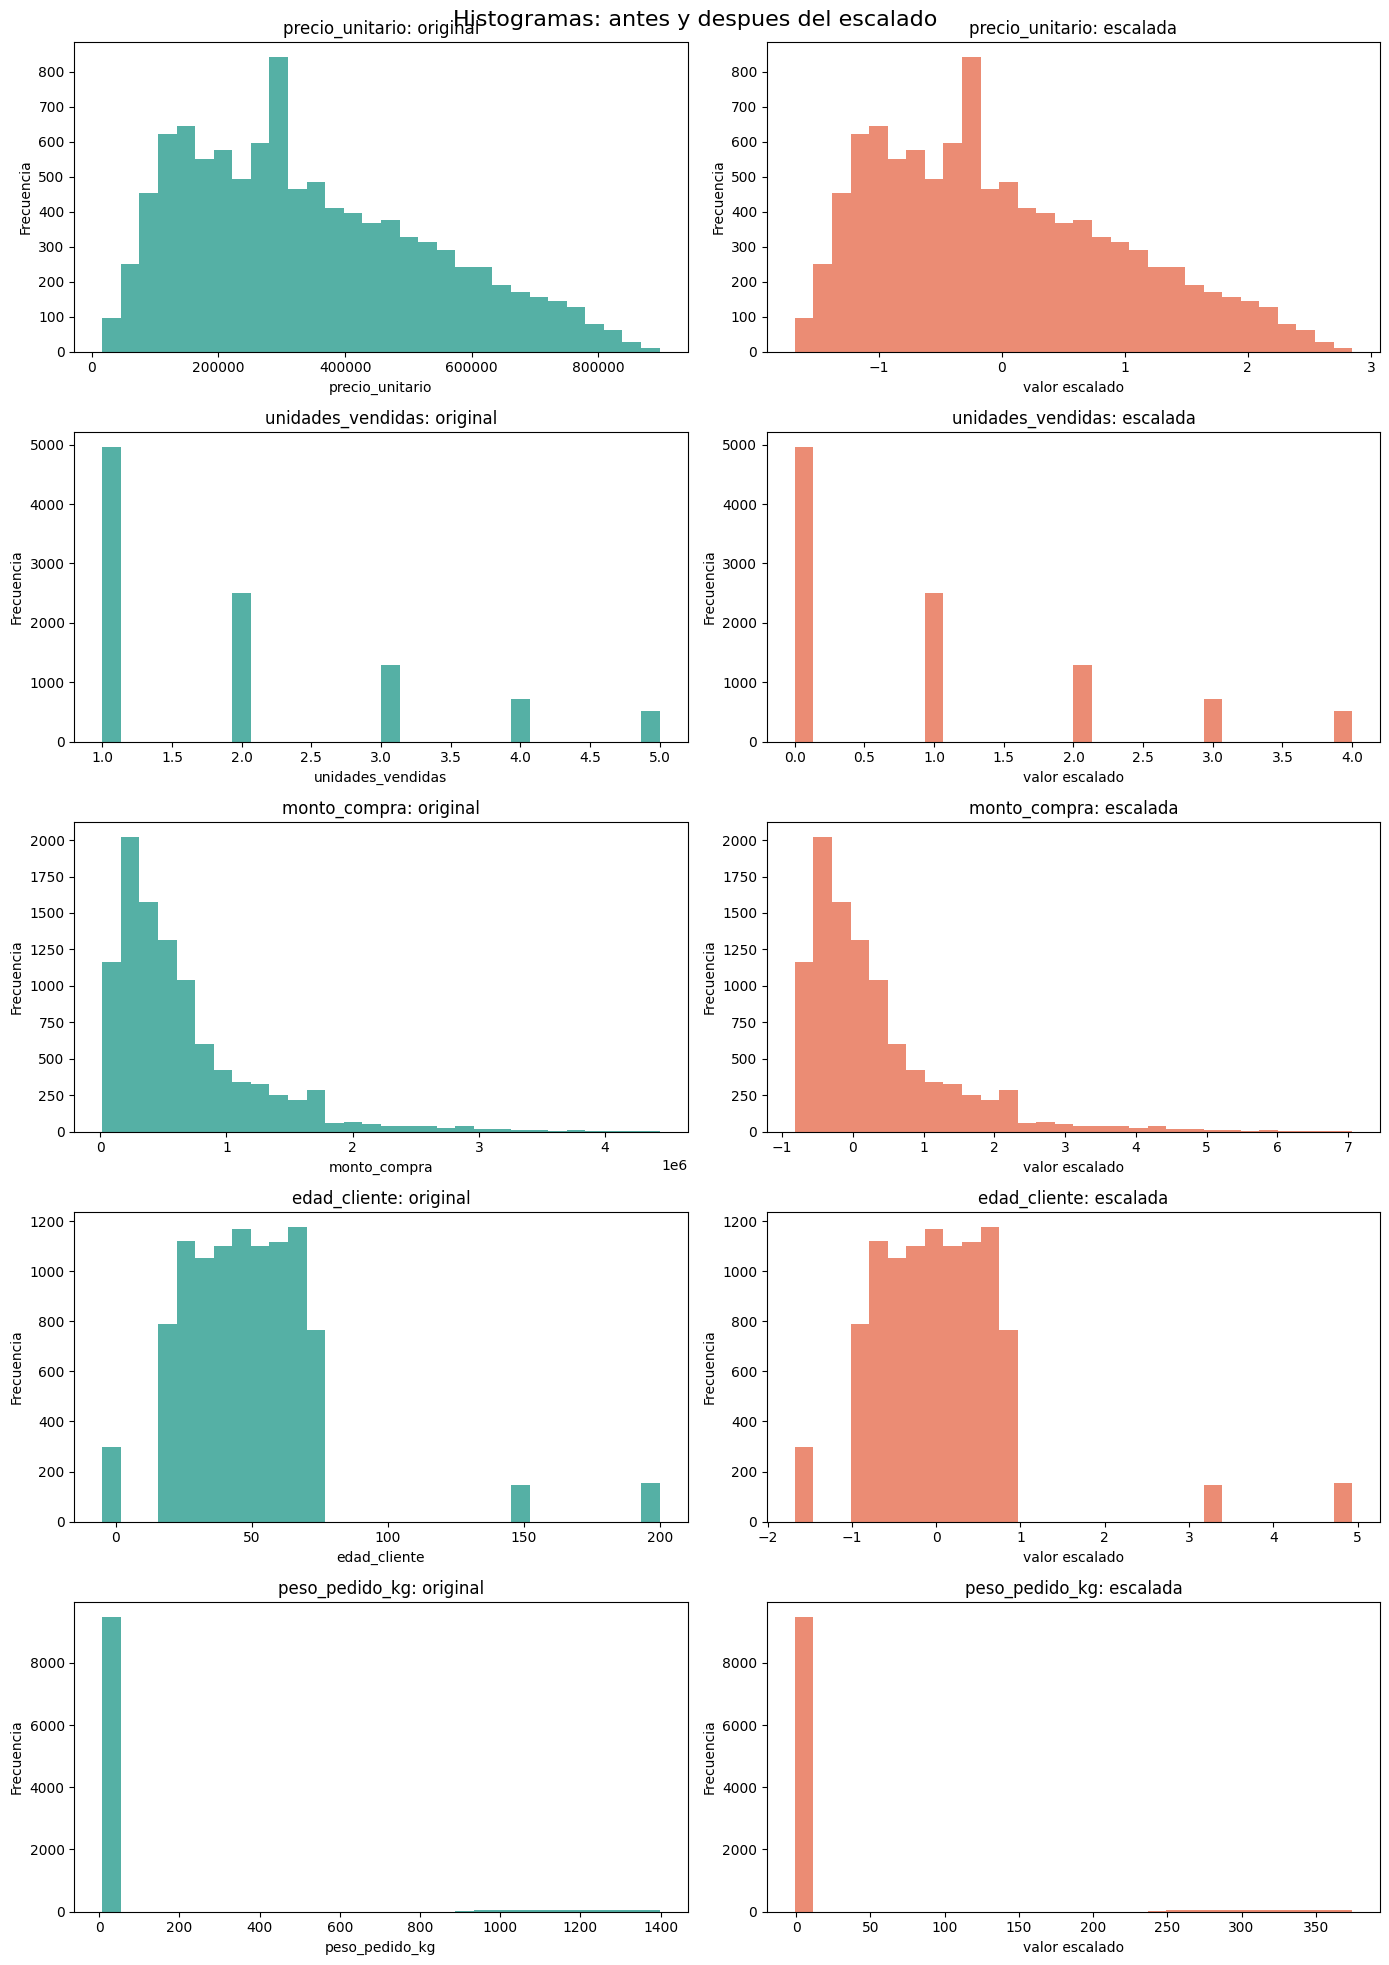

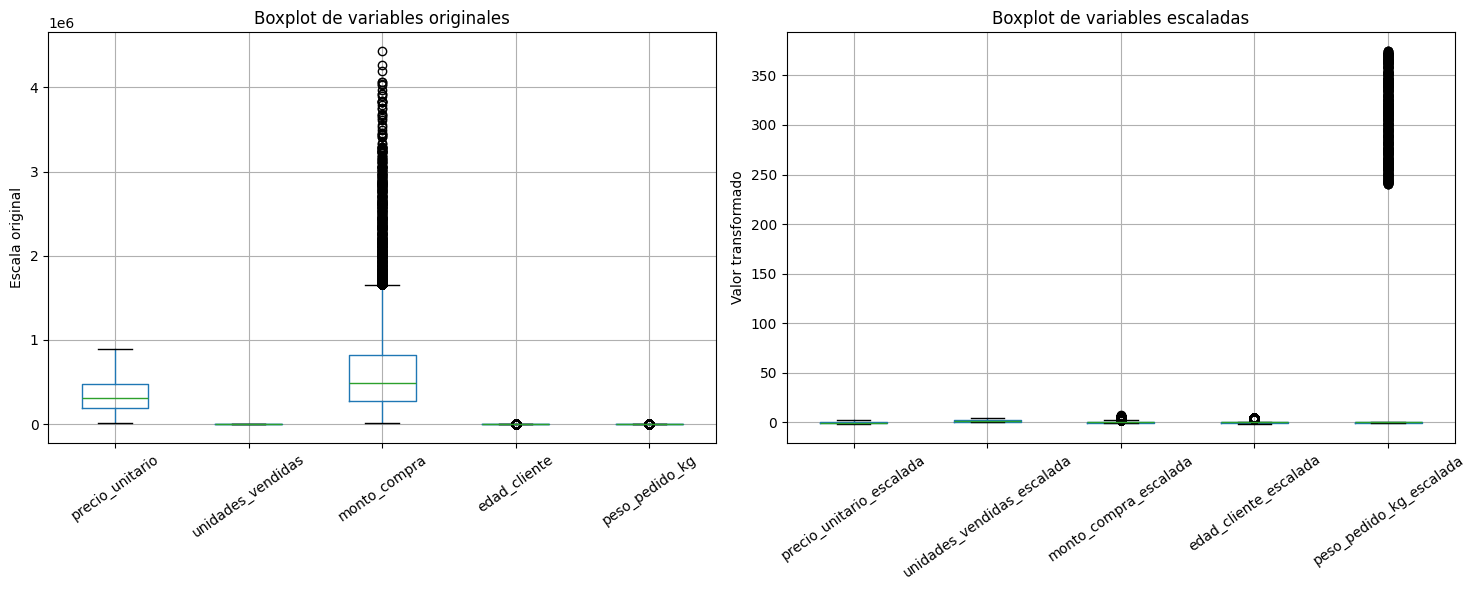

In [5]:
muestra = df_salida.sample(n=min(10000, len(df_salida)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(len(variables_escaladas), 2, figsize=(14, 4 * len(variables_escaladas)))
for fila, columna in enumerate(variables_escaladas):
    nombre = f'{columna}_escalada'
    axes[fila, 0].hist(muestra[columna], bins=30, color='#2a9d8f', alpha=0.8)
    axes[fila, 0].set_title(f'{columna}: original')
    axes[fila, 1].hist(muestra[nombre], bins=30, color='#e76f51', alpha=0.8)
    axes[fila, 1].set_title(f'{columna}: escalada')
    axes[fila, 0].set_ylabel('Frecuencia')
    axes[fila, 1].set_ylabel('Frecuencia')
    axes[fila, 0].set_xlabel(columna)
    axes[fila, 1].set_xlabel('valor escalado')
fig.suptitle('Histogramas: antes y despues del escalado', fontsize=16)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
muestra[variables_escaladas].boxplot(ax=axes[0], rot=35)
axes[0].set_title('Boxplot de variables originales')
axes[0].set_ylabel('Escala original')
muestra[[f'{c}_escalada' for c in variables_escaladas]].boxplot(ax=axes[1], rot=35)
axes[1].set_title('Boxplot de variables escaladas')
axes[1].set_ylabel('Valor transformado')
fig.tight_layout()
plt.show()

## 5. Checklist de entrega

- [x] Dataset de la Semana 7 utilizado.
- [x] Variables relevantes y exclusiones documentadas.
- [x] `train_test_split` ejecutado antes de cualquier `fit`.
- [x] Cada escalador ajustado solo con train y aplicado a train y prueba.
- [x] Tecnica justificada por columna.
- [x] Histograma y boxplot antes/despues incluidos.
- [x] Columnas originales conservadas y columnas escaladas agregadas.
- [x] Exportacion a `S08_PD_Pallares_DatasetEscalado.csv`.